# Semantic Embedding Clustering of SMS Messages

This notebook explores SMS message structure in an unsupervised setting using transformer-based sentence embeddings.

The workflow focuses on:

- generating semantic embeddings for each message
- normalizing the embedding vectors for distance-based clustering
- comparing clustering behavior with KMeans and DBSCAN
- inspecting cluster quality with silhouette-based analysis
- visualizing the reduced embedding space in three dimensions

The objective is to understand whether meaningful semantic grouping emerges in the embedding space, even without using the spam labels directly for training.

---

**Date:** 2026-04-16

**Author:** Sergej Schweizer

## Table of Contents

- [Data Load](#data-load)
- [Embedding model](#embedding-model)
- [Clustering, finding optimal number of clusters](#clustering-finding-optimal-number-of-clusters)
- [Kmeans Analysis](#kmeans-analysis)
- [Dimensionality reduction](#dimensionality-reduction)

In [1]:
import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from tqdm import TqdmExperimentalWarning

from src.utils import (
    compute_clustering_metric,
    plot_clustering_metric,
    preprocess_embedding,
    plot_kmeans_clusters_3d,
    plot_embeddings_3d_by_label
)

ImportError: cannot import name 'plot_embeddings_3d_by_label' from 'src.utils' (c:\code\sms-spam-classifier\.venv\Lib\site-packages\src\utils.py)

## Data Load

In [ ]:
# Load the SMS dataset and standardize the base dataframe.
df = pd.read_csv(
    "../data/raw/spam.csv", 
    encoding="cp1252", 
    usecols=["v1", "v2"]
    ).rename(columns={"v1": "label", "v2": "message"})
df.sample(5)

,label,message
3430,ham,Yeah if we do have to get a random dude we nee...
1232,ham,1's finish meeting call me.
2279,ham,"Sorry, I'll call later in meeting"
1832,ham,What time is ur flight tmr?
255,ham,Don't necessarily expect it to be done before ...


## Embedding model

**Trade-off:**
I chose the model all-MiniLM-L6-v2 because it provides an excellent trade-off between computational efficiency and semantic quality. The model outputs embeddings with size 384, which is compact enough for efficient processing while still preserving meaningful semantic structure. As a lightweight model, it is fast enough to handle larger datasets and can run locally on a CPU without requiring specialized hardware. At the same time, it produces sufficiently accurate embeddings to reliably group semantically similar SMS messages. For clustering, maximum precision is less important than a consistent representation of similarity, and this model achieves that balance very effectively.


In [ ]:
# Apply preprocessing to the message column
df["clean_message"] = df["message"].apply(preprocess_embedding)
df.sample(5)

,label,message,clean_message
3388,ham,O. Guess they both got screwd,O. Guess they both got screwd
5475,ham,Dhoni have luck to win some big title.so we wi...,Dhoni have luck to win some big title.so we wi...
4896,ham,I cant pick the phone right now. Pls send a me...,I cant pick the phone right now. Pls send a me...
3681,ham,"Hello, hello, hi lou sorry it took so long 2 r...","Hello, hello, hi lou sorry it took so long 2 r..."
2008,ham,See the forwarding message for proof,See the forwarding message for proof


In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

df["embedding"] = model.encode(
    df["clean_message"].tolist(),
    show_progress_bar=True
).tolist()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/175 [00:00<?, ?it/s]

In [ ]:
df.sample(3)

,label,message,clean_message,embedding
4074,ham,"God picked up a flower and dippeditinaDEW, lov...","God picked up a flower and dippeditinaDEW, lov...","[0.006683753337711096, 0.13628508150577545, 0...."
337,ham,Just sleeping..and surfing,Just sleeping..and surfing,"[0.05574030429124832, -0.09055127203464508, 0...."
5364,spam,Call 09095350301 and send our girls into eroti...,Call 09095350301 and send our girls into eroti...,"[-0.031244266778230667, 0.021514765918254852, ..."


## Clustering, finding optimal number of clusters

**Normalization**
You normalize embeddings to make them comparable in direction rather than magnitude. Most text embeddings are designed so that **semantic similarity is captured by angles (cosine similarity)**, not raw vector lengths. Without normalization, vectors with larger norms can dominate distance-based methods like KMeans or DBSCAN, leading to distorted clusters. L2 normalization ensures all vectors lie on the unit sphere, making distances consistent and clustering results more stable and meaningful.

In [ ]:
X = np.vstack(df["embedding"].values)
X = normalize(X, norm="l2")

## Kmeans Analysis

KMeans inertia:   0%|          | 0/38 [00:00<?, ?it/s]

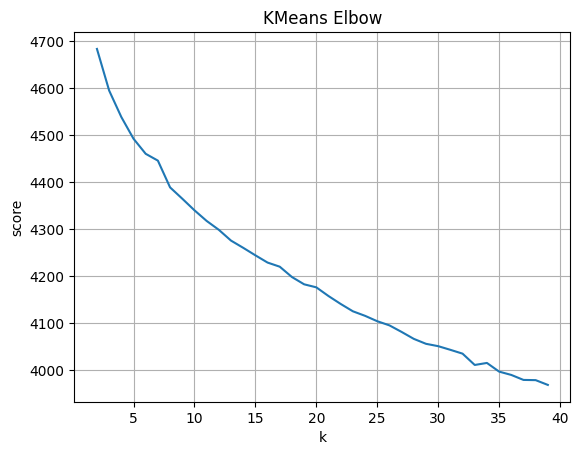

In [ ]:
df_elbow = compute_clustering_metric(
    X,
    method="kmeans",
    metric="inertia",
    param_range=range(2, 40)
)

plot_clustering_metric(df_elbow, "KMeans Elbow")

**Implications**
- The “elbow” is not extremely sharp, but the most reasonable bend appears around:
k ≈ 8 to 12
- This suggests that the data likely has a moderate number of natural groupings, rather than being best described by many fine-grained clusters.
- Choosing k > 20 is probably over-segmentation: it reduces inertia slightly but likely starts splitting meaningful clusters into smaller, less interpretable subgroups.
- Choosing k < 8 may underfit: clusters are likely too broad and mixed.

KMeans silhouette:   0%|          | 0/38 [00:00<?, ?it/s]

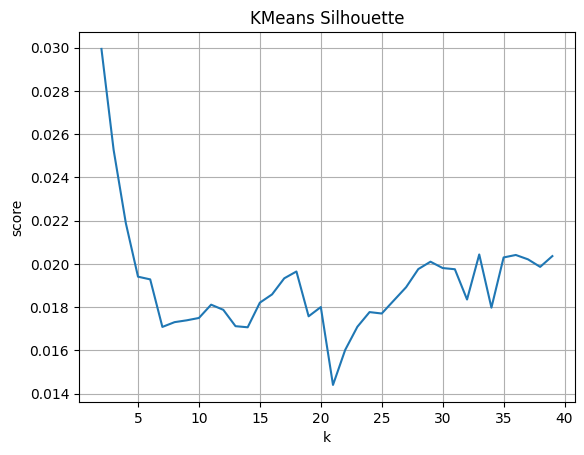

In [ ]:
df_silhouette = compute_clustering_metric(
    X,
    method="kmeans",
    metric="silhouette",
    param_range=range(2, 40)
)

plot_clustering_metric(df_silhouette, "KMeans Silhouette")

**Implications**

- If you choose strictly by silhouette score, the best number of clusters here is 2.
- The fact that all scores are very low means the clustering structure is weak overall, even at the “best” k.
- So the result suggests: 2 is the least-bad KMeans split in this embedding space, but the data does not appear to separate into strong, well-defined KMeans clusters.

DB-SCAN Analysis

DBSCAN silhouette:   0%|          | 0/5 [00:00<?, ?it/s]

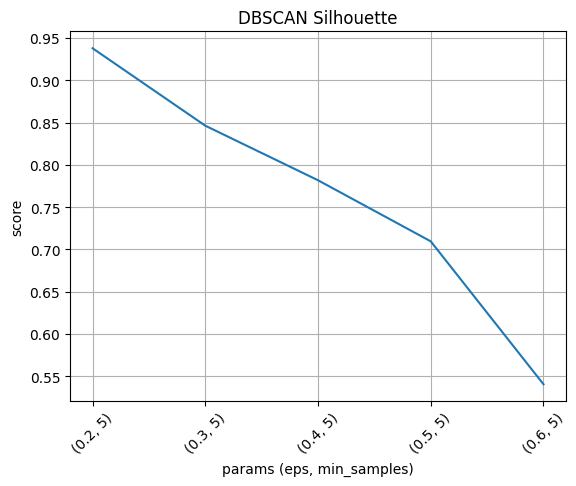

In [ ]:
dbscan_grid = [
    (0.2, 5),
    (0.3, 5),
    (0.4, 5),
    (0.5, 5),
    (0.6, 5),
]

df_dbscan = compute_clustering_metric(
    X,
    method="dbscan",
    metric="silhouette",
    dbscan_params=dbscan_grid
)

plot_clustering_metric(df_dbscan, "DBSCAN Silhouette")

In [ ]:
model = DBSCAN(eps=0.2, min_samples=5)
labels = model.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print("clusters:", n_clusters)
print("noise points:", n_noise)


clusters: 7
noise points: 5491


The DBSCAN analysis suggests that the best clustering result among the tested parameter settings is achieved at the smallest `eps`, where the silhouette score is highest. For that best setting, DBSCAN identifies `7` clusters, but classifies `5491` points as noise. This means the algorithm finds a few very compact and well-separated dense groups, while leaving most messages unassigned. In short, DBSCAN captures only a small core structure in the embedding space rather than providing a broad clustering of the full dataset.

## Dimensionality reduction

We project the embedding space into three dimensions to make the semantic structure visually interpretable, then apply KMeans clustering to group similar messages into a fixed number of clusters. The result is displayed as an interactive 3D plot, which allows us to inspect how the clustered messages are distributed in the reduced semantic space and whether meaningful separation between groups can be observed.

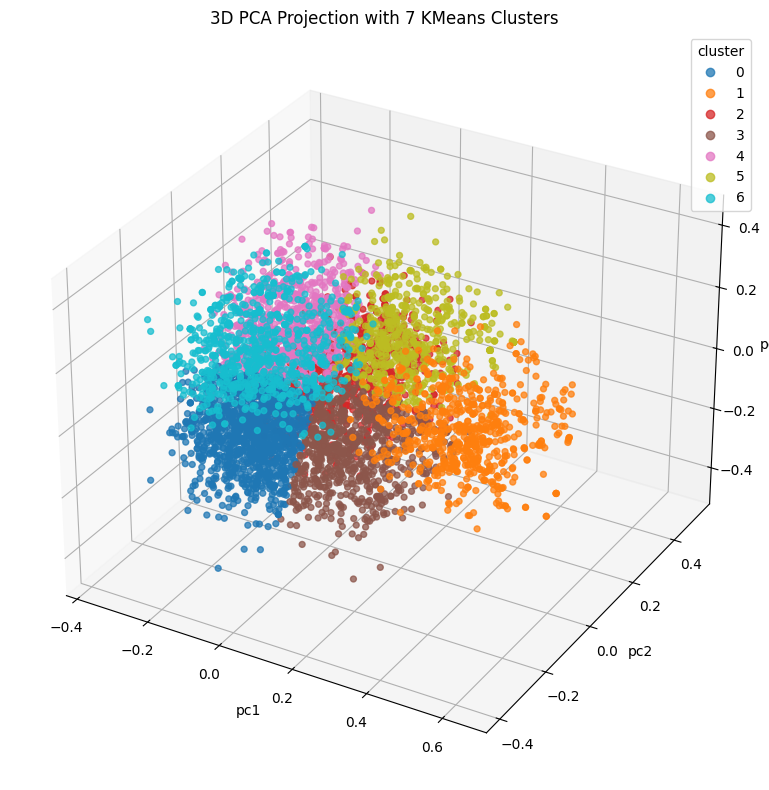

In [ ]:
fig = plot_kmeans_clusters_3d(X, df, n_clusters=7)

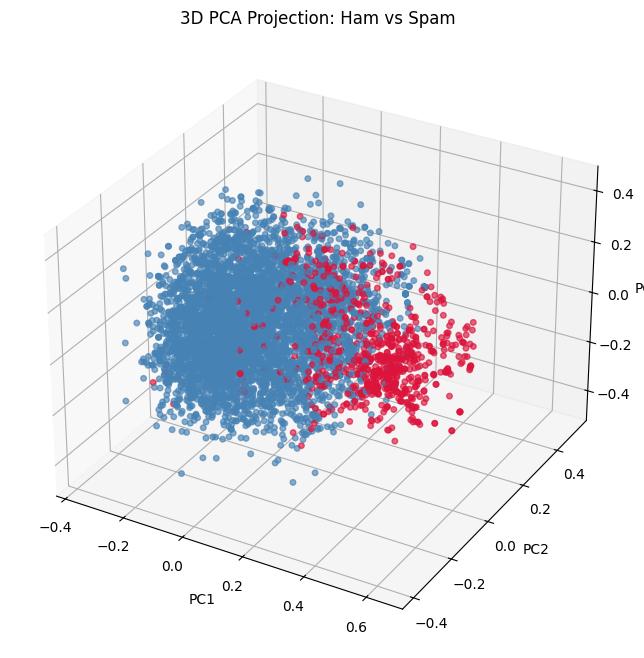

In [ ]:
fig, ax = plot_embeddings_3d_by_label(
    df,
    embedding_col="embedding",
    label_col="label",
    spam_color="crimson",
    ham_color="steelblue",
    point_size=16,
    alpha=0.65,
)

This 3D visualization shows SMS embeddings after reducing their dimensionality from 384 to 3 using PCA for better visibility. While some separation between ham and spam is visible, there is a clear gray overlap zone where both classes mix, indicating semantically ambiguous messages